# MNIST Smoothing Radius: Query and Neighbour Explanations

This notebook selects a small set of query samples and visualizes:

- the query digit
- the query explanation
- the explanations of its nearest like-neighbours

across increasing smoothing radii, using the same cosine / `k=25` setup as the main sweep.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from captum.attr import IntegratedGradients
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

current_dir = Path.cwd()
if current_dir.name == "experiments":
    SRC_DIR = current_dir.parent
elif (current_dir / "src").exists():
    SRC_DIR = current_dir / "src"
else:
    SRC_DIR = current_dir

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from case_align.metrics import safe_normalise_rows
from train_mnist_model import MNISTNet, set_seed

MODEL_PATH = SRC_DIR / "models" / "mnist" / "mnist_best_model.pt"
ARTIFACT_PATH = SRC_DIR / "explanations" / "mnist" / "mnist_explanations.pt"
DATA_DIR = SRC_DIR / "data"
RESULT_DIR = SRC_DIR / "results" / "mnist_smoothing_radius_sensitivity_vs_case_align_cosine_k25"
SCORES_PATH = RESULT_DIR / "mnist_smoothing_radius_scores_cosine_k25.csv"
CONFIG_PATH = RESULT_DIR / "mnist_smoothing_radius_config_cosine_k25.json"
OUTPUT_DIR = RESULT_DIR / "query_neighbour_visualizations"

N_SELECTED_QUERIES = 5
N_NEIGHBOURS = 3
N_DISPLAY_RADII = 6
SEED = 42

print(f"SRC_DIR: {SRC_DIR}")
print(f"Scores: {SCORES_PATH}")
print(f"Config: {CONFIG_PATH}")

SRC_DIR: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src
Scores: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_radius_sensitivity_vs_case_align_cosine_k25/mnist_smoothing_radius_scores_cosine_k25.csv
Config: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_radius_sensitivity_vs_case_align_cosine_k25/mnist_smoothing_radius_config_cosine_k25.json


In [2]:
def _configure_ssl_for_macos() -> None:
    import ssl
    ssl._create_default_https_context = ssl._create_unverified_context


def load_model(model_path: Path, device: torch.device) -> MNISTNet:
    checkpoint = torch.load(model_path, map_location=device)
    model = MNISTNet()
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    elif isinstance(checkpoint, dict):
        model.load_state_dict(checkpoint)
    else:
        raise RuntimeError("Unsupported checkpoint format")
    model.to(device)
    model.eval()
    return model


def load_full_test_split(data_dir: Path):
    _configure_ssl_for_macos()
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    test_dataset = datasets.MNIST(str(data_dir), train=False, download=True, transform=transform)
    loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

    image_chunks, label_chunks = [], []
    for images, labels in loader:
        image_chunks.append(images)
        label_chunks.append(labels)

    return torch.cat(image_chunks, dim=0).float(), torch.cat(label_chunks, dim=0).numpy().astype(int)


def cosine_distance_context(matrix, epsilon=1e-8):
    matrix_raw = np.asarray(matrix, dtype=float)
    return {
        "matrix_raw": matrix_raw,
        "matrix_repr": safe_normalise_rows(matrix_raw, eps=epsilon),
        "epsilon": float(epsilon),
    }


def cosine_row_distances(query_vec, context):
    query_repr = safe_normalise_rows(np.asarray(query_vec, dtype=float)[None, :], eps=context["epsilon"])[0]
    similarity = context["matrix_repr"] @ query_repr
    return np.clip(1.0 - 0.5 * (similarity + 1.0), 0.0, 1.0)


def gaussian_kernel2d(radius, device, dtype):
    sigma = float(radius)
    kernel_size = max(3, int(2 * np.ceil(3 * sigma) + 1))
    coords = torch.arange(kernel_size, device=device, dtype=dtype) - (kernel_size - 1) / 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    g = g / g.sum()
    kernel = torch.outer(g, g)
    kernel = kernel / kernel.sum()
    return kernel.unsqueeze(0).unsqueeze(0)


def smooth_attributions(attrs, radius):
    kernel = gaussian_kernel2d(radius, attrs.device, attrs.dtype)
    kernel_size = kernel.shape[-1]
    channels = attrs.shape[1]
    kernel = kernel.expand(channels, 1, kernel_size, kernel_size)
    return F.conv2d(attrs, kernel, padding=kernel_size // 2, groups=channels)


def compute_retrieval_ig_attributions(model, images, pred_labels, baseline, batch_size, device):
    ig = IntegratedGradients(model)
    chunks = []
    n_batches = (len(images) + batch_size - 1) // batch_size
    for batch_idx, start in enumerate(range(0, len(images), batch_size), start=1):
        end = min(start + batch_size, len(images))
        xb = images[start:end].to(device).clone().detach().requires_grad_(True)
        target_tensor = torch.as_tensor(pred_labels[start:end], dtype=torch.long, device=device)
        attrs = ig.attribute(xb, baselines=baseline.to(device).expand_as(xb), target=target_tensor)
        chunks.append(attrs.detach().cpu().float())
        if batch_idx == 1 or batch_idx == n_batches or batch_idx % max(n_batches // 10, 1) == 0:
            print(f"  attribution batches: {batch_idx}/{n_batches}")
    return torch.cat(chunks, dim=0)


def top_like_neighbours(query_index, query_label, retrieval_labels, problem_context, k):
    dprob_all = cosine_row_distances(problem_context["matrix_raw"][query_index], problem_context)
    like_mask = retrieval_labels == int(query_label)
    like_mask[query_index] = False
    like_indices = np.where(like_mask)[0]
    like_dists = dprob_all[like_indices]
    order = np.argsort(like_dists)
    neigh_indices = like_indices[order[:k]]
    neigh_dists = like_dists[order[:k]]
    return neigh_indices.astype(int), neigh_dists.astype(float)


In [3]:
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

config = json.loads(CONFIG_PATH.read_text())
scores_df = pd.read_csv(SCORES_PATH)
artifact = torch.load(ARTIFACT_PATH, map_location="cpu")

query_images = artifact["images"].float()
query_labels = artifact["labels"].numpy().astype(int)
query_pred_labels = artifact["pred_labels"].numpy().astype(int)
query_retrieval_indices = artifact["sample_indices"].numpy().astype(int)
baseline = artifact["baseline"].float()

max_query_samples = int(config["max_query_samples"])
query_images = query_images[:max_query_samples]
query_labels = query_labels[:max_query_samples]
query_pred_labels = query_pred_labels[:max_query_samples]
query_retrieval_indices = query_retrieval_indices[:max_query_samples]

all_radii = np.array(config["smoothing_radii"], dtype=float)
display_radii = np.unique(np.round(np.linspace(all_radii.min(), all_radii.max(), N_DISPLAY_RADII), 2))

pivot = scores_df.pivot_table(index="sample_position", columns="smoothing_radius", values=["case_align_S_plus", "captum_sensitivity"])
pivot.columns = [f"{metric}_{radius:.2f}" for metric, radius in pivot.columns]
low_r = float(all_radii.min())
high_r = float(all_radii.max())
pivot["delta_case_align"] = pivot[f"case_align_S_plus_{low_r:.2f}"] - pivot[f"case_align_S_plus_{high_r:.2f}"]
pivot["abs_delta_case_align"] = pivot["delta_case_align"].abs()
selected_positions = pivot.sort_values("abs_delta_case_align", ascending=False).head(N_SELECTED_QUERIES).index.tolist()

print(f"Selected query positions: {selected_positions}")
print(f"Display radii: {display_radii.tolist()}")
display(pivot.loc[selected_positions, [f"case_align_S_plus_{low_r:.2f}", f"case_align_S_plus_{high_r:.2f}", "delta_case_align", "abs_delta_case_align"]].round(4))

Using device: cpu
Selected query positions: [4, 27, 5, 1, 24]
Display radii: [0.1, 0.48, 0.86, 1.24, 1.62, 2.0]


,case_align_S_plus_0.10,case_align_S_plus_2.00,delta_case_align,abs_delta_case_align
sample_position,,,,
4,0.3338,0.8509,-0.5172,0.5172
27,0.4686,0.9048,-0.4362,0.4362
5,0.4400,0.8732,-0.4332,0.4332
1,0.4207,0.8534,-0.4327,0.4327
24,0.4564,0.8838,-0.4275,0.4275


In [4]:
model = load_model(MODEL_PATH, device)
retrieval_images, retrieval_labels = load_full_test_split(DATA_DIR)

def predict_labels_for_images(model, images, batch_size, device):
    pred_chunks = []
    with torch.no_grad():
        for start in range(0, len(images), batch_size):
            end = min(start + batch_size, len(images))
            logits = model(images[start:end].to(device))
            preds = torch.softmax(logits, dim=1).argmax(dim=1)
            pred_chunks.append(preds.detach().cpu().numpy().astype(int))
    return np.concatenate(pred_chunks)

retrieval_pred_labels = predict_labels_for_images(model, retrieval_images, batch_size=256, device=device)
raw_retrieval_attrs = compute_retrieval_ig_attributions(
    model=model,
    images=retrieval_images,
    pred_labels=retrieval_pred_labels,
    baseline=baseline,
    batch_size=256,
    device=device,
)

problem_context = cosine_distance_context(retrieval_images.view(len(retrieval_images), -1).numpy())
smoothed_attr_cache = {}
for radius in display_radii:
    smoothed_attr_cache[float(radius)] = smooth_attributions(raw_retrieval_attrs.to(device), float(radius)).cpu().numpy()
print("Cached smoothed attributions for display radii.")

  attribution batches: 1/40


  attribution batches: 4/40


  attribution batches: 8/40


  attribution batches: 12/40


  attribution batches: 16/40


...

  attribution batches: 28/40


  attribution batches: 32/40


  attribution batches: 36/40


  attribution batches: 40/40


Cached smoothed attributions for display radii.


## Query and Neighbour Explanation Grids

Sample 4 | test idx 8255 | true=4 pred=4 | Case Align 0.10->2.00: 0.3338->0.8509 | Sensitivity 0.10->2.00: 0.4913->0.1355
Neighbours: idx 6780 (d=0.1465), idx 6761 (d=0.1640), idx 9203 (d=0.1646)


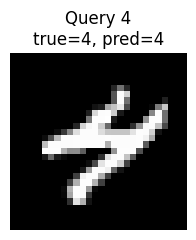

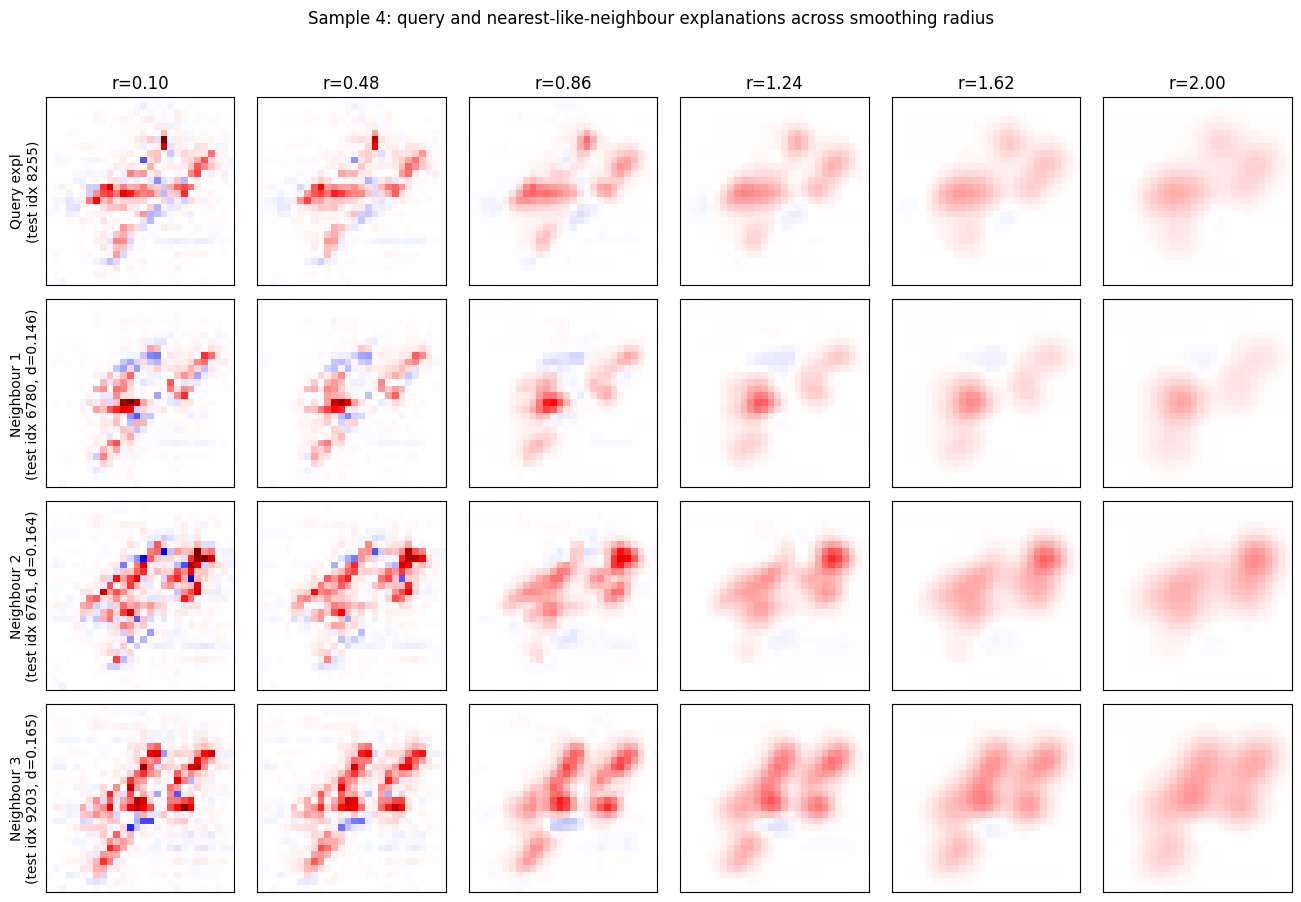

Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_radius_sensitivity_vs_case_align_cosine_k25/query_neighbour_visualizations/query_04_neighbour_explanations.png

Sample 27 | test idx 6736 | true=3 pred=3 | Case Align 0.10->2.00: 0.4686->0.9048 | Sensitivity 0.10->2.00: 0.7762->0.1323
Neighbours: idx 6985 (d=0.0741), idx 6714 (d=0.0772), idx 2955 (d=0.0799)


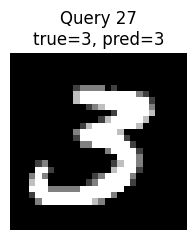

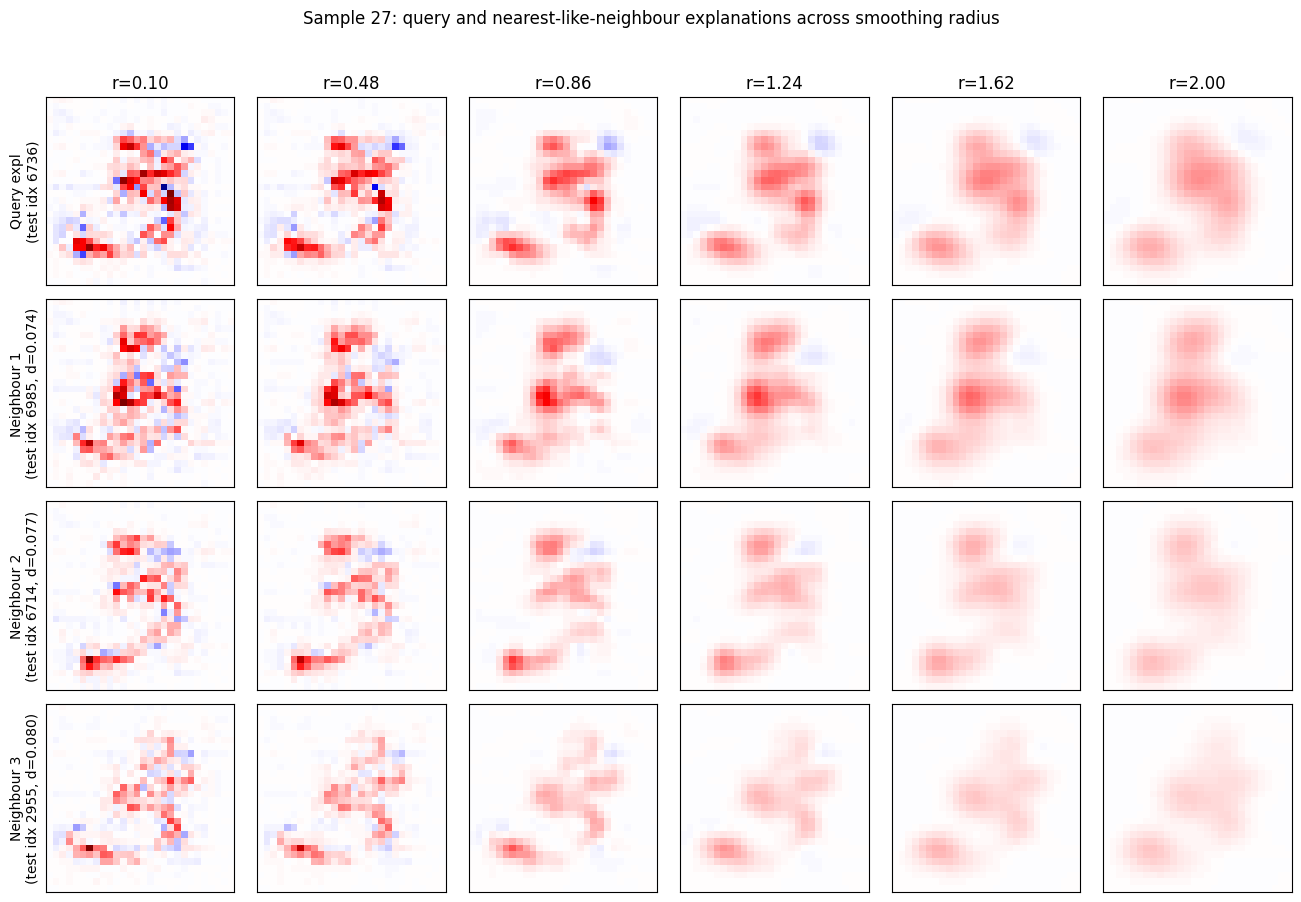

Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_radius_sensitivity_vs_case_align_cosine_k25/query_neighbour_visualizations/query_27_neighbour_explanations.png

Sample 5 | test idx 5145 | true=6 pred=6 | Case Align 0.10->2.00: 0.4400->0.8732 | Sensitivity 0.10->2.00: 0.4112->0.0992
Neighbours: idx 5115 (d=0.0550), idx 4160 (d=0.0802), idx 8744 (d=0.0907)


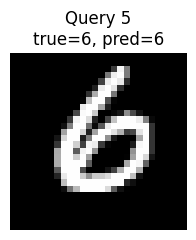

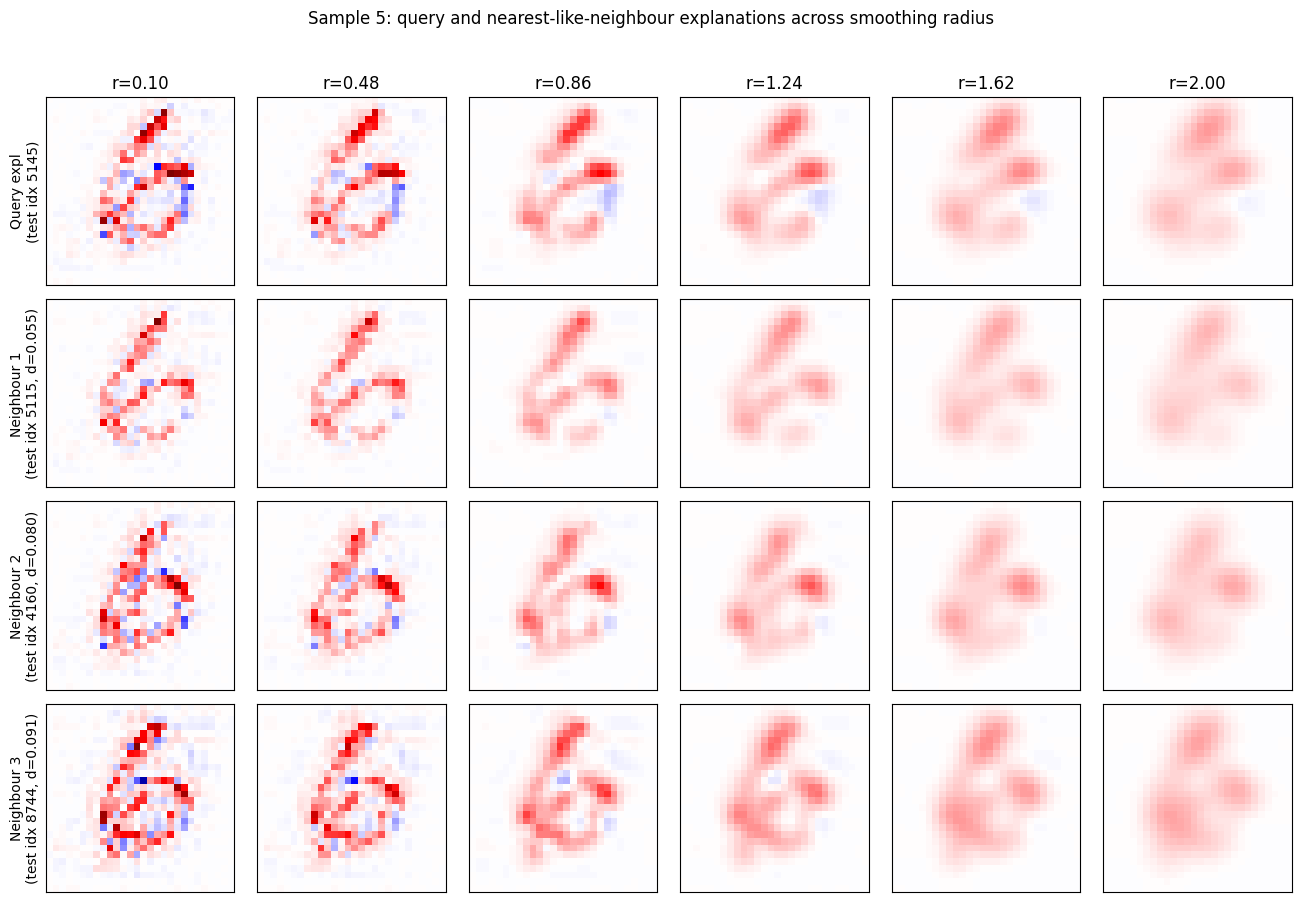

Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_radius_sensitivity_vs_case_align_cosine_k25/query_neighbour_visualizations/query_05_neighbour_explanations.png

Sample 1 | test idx 9693 | true=6 pred=6 | Case Align 0.10->2.00: 0.4207->0.8534 | Sensitivity 0.10->2.00: 0.5773->0.1391
Neighbours: idx 9607 (d=0.1475), idx 7466 (d=0.1492), idx 3252 (d=0.1523)


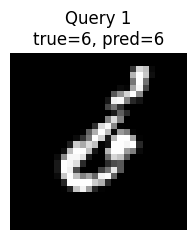

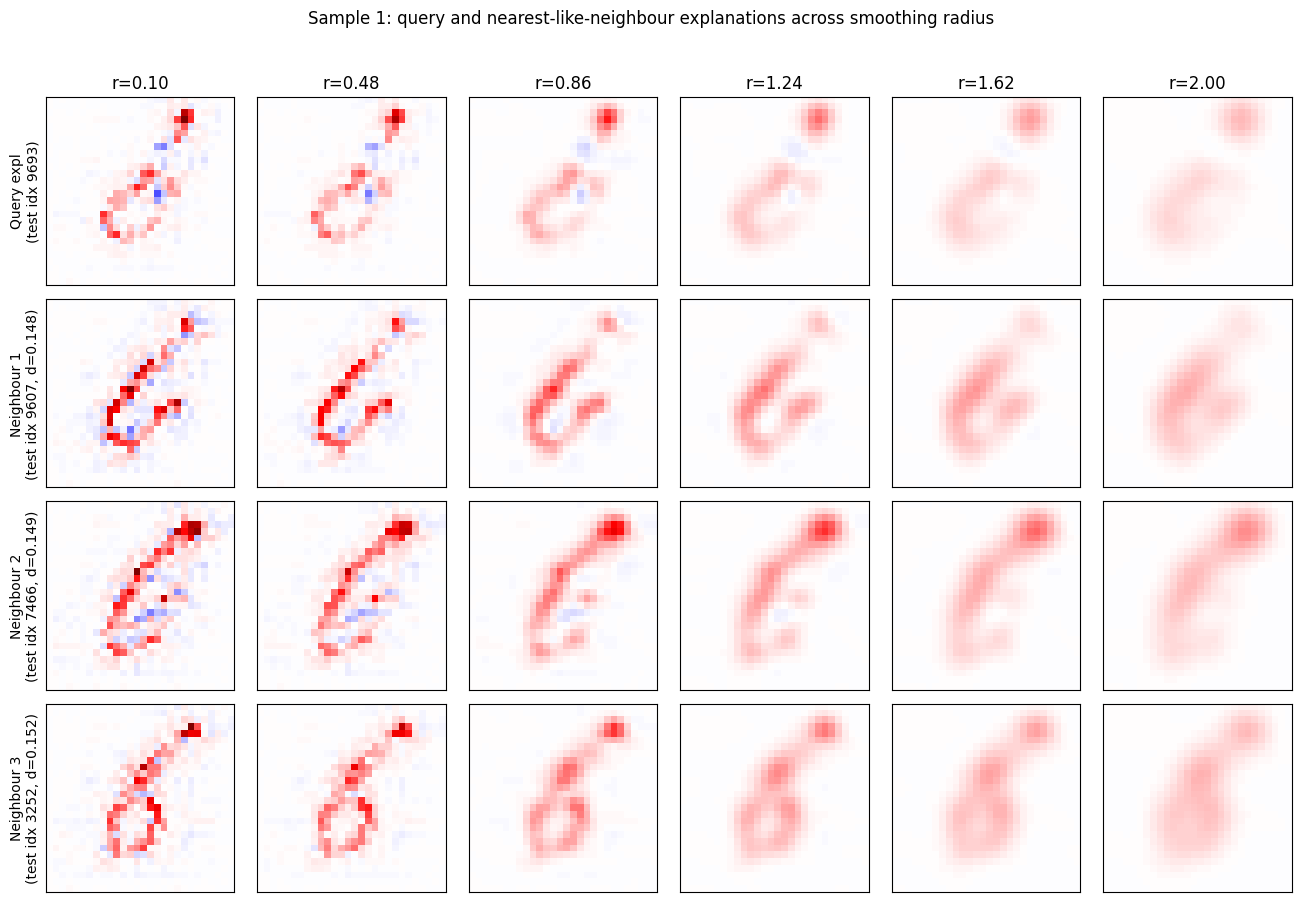

Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_radius_sensitivity_vs_case_align_cosine_k25/query_neighbour_visualizations/query_01_neighbour_explanations.png

Sample 24 | test idx 501 | true=9 pred=9 | Case Align 0.10->2.00: 0.4564->0.8838 | Sensitivity 0.10->2.00: 0.6762->0.1512
Neighbours: idx 3483 (d=0.0669), idx 4122 (d=0.0798), idx 9404 (d=0.0847)


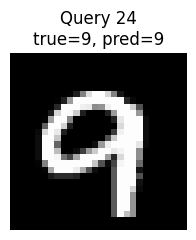

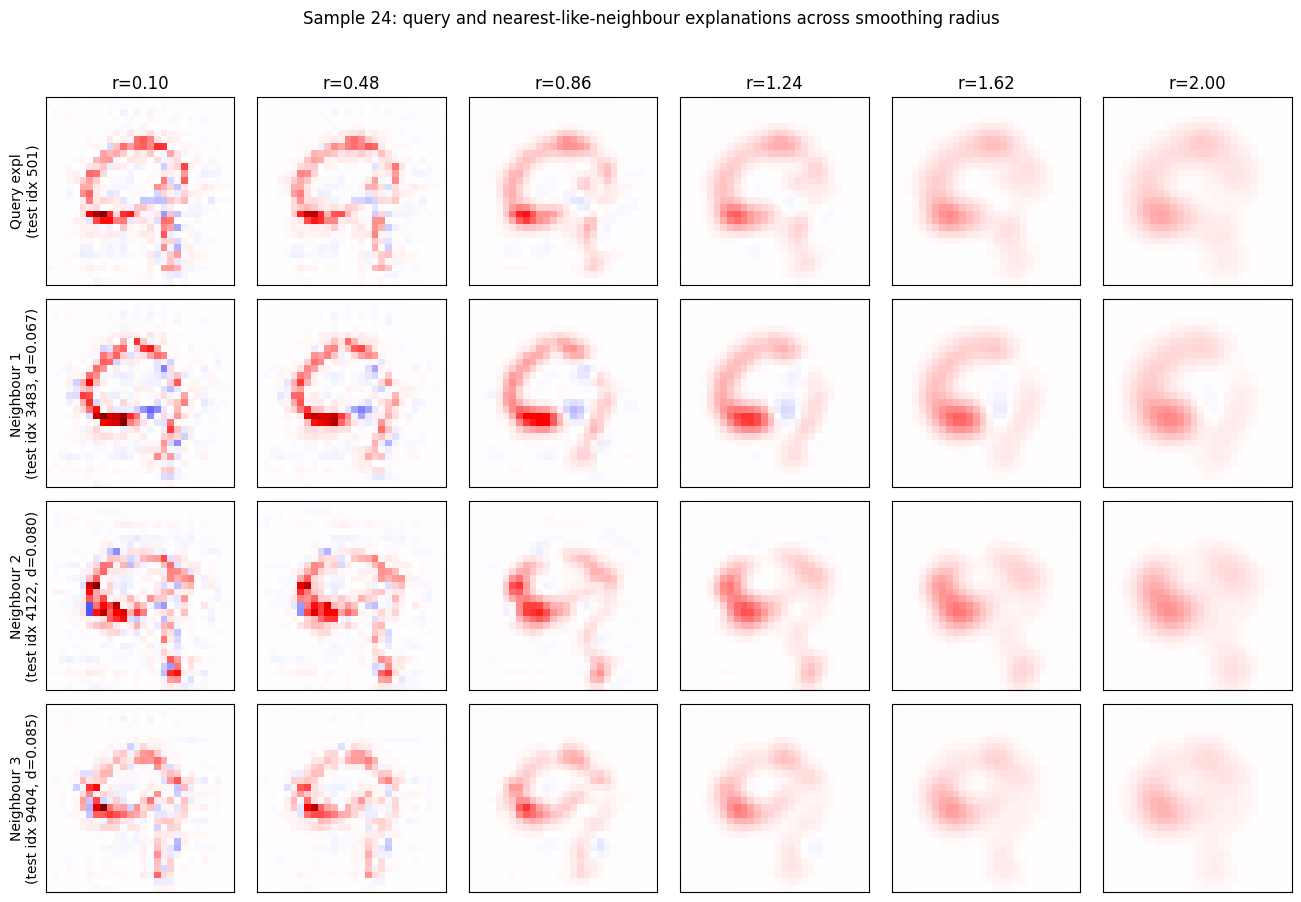

Saved: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_smoothing_radius_sensitivity_vs_case_align_cosine_k25/query_neighbour_visualizations/query_24_neighbour_explanations.png



In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for sample_pos in selected_positions:
    retrieval_index = int(query_retrieval_indices[sample_pos])
    query_label = int(query_labels[sample_pos])
    pred_label = int(query_pred_labels[sample_pos])

    neighbour_indices, neighbour_dists = top_like_neighbours(
        query_index=retrieval_index,
        query_label=query_label,
        retrieval_labels=retrieval_labels,
        problem_context=problem_context,
        k=N_NEIGHBOURS,
    )

    low_row = scores_df[(scores_df["sample_position"] == sample_pos) & (scores_df["smoothing_radius"] == low_r)].iloc[0]
    high_row = scores_df[(scores_df["sample_position"] == sample_pos) & (scores_df["smoothing_radius"] == high_r)].iloc[0]

    print(
        f"Sample {sample_pos} | test idx {retrieval_index} | true={query_label} pred={pred_label} | "
        f"Case Align {low_r:.2f}->{high_r:.2f}: {low_row['case_align_S_plus']:.4f}->{high_row['case_align_S_plus']:.4f} | "
        f"Sensitivity {low_r:.2f}->{high_r:.2f}: {low_row['captum_sensitivity']:.4f}->{high_row['captum_sensitivity']:.4f}"
    )
    print(
        "Neighbours: " + ", ".join(
            [f"idx {int(idx)} (d={float(dist):.4f})" for idx, dist in zip(neighbour_indices, neighbour_dists)]
        )
    )

    fig_query, ax_query = plt.subplots(1, 1, figsize=(2.5, 2.5))
    ax_query.imshow(query_images[sample_pos, 0].numpy(), cmap="gray")
    ax_query.set_title(f"Query {sample_pos}\ntrue={query_label}, pred={pred_label}")
    ax_query.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close(fig_query)

    entity_labels = [f"Query expl\n(test idx {retrieval_index})"] + [
        f"Neighbour {i + 1}\n(test idx {int(idx)}, d={float(dist):.3f})"
        for i, (idx, dist) in enumerate(zip(neighbour_indices, neighbour_dists))
    ]
    entity_indices = [retrieval_index] + neighbour_indices.tolist()

    fig, axes = plt.subplots(
        nrows=len(entity_indices),
        ncols=len(display_radii),
        figsize=(2.2 * len(display_radii), 2.2 * len(entity_indices)),
    )
    if len(entity_indices) == 1:
        axes = np.expand_dims(axes, axis=0)
    if len(display_radii) == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_idx, (entity_label, entity_index) in enumerate(zip(entity_labels, entity_indices)):
        vmax = 1e-8
        for radius in display_radii:
            vmax = max(vmax, np.max(np.abs(smoothed_attr_cache[float(radius)][entity_index, 0])))

        for col_idx, radius in enumerate(display_radii):
            ax = axes[row_idx, col_idx]
            attr = smoothed_attr_cache[float(radius)][entity_index, 0]
            ax.imshow(attr, cmap="seismic", vmin=-vmax, vmax=vmax)
            if row_idx == 0:
                ax.set_title(f"r={float(radius):.2f}")
            if col_idx == 0:
                ax.set_ylabel(entity_label)
            ax.set_xticks([])
            ax.set_yticks([])

    fig.suptitle(
        f"Sample {sample_pos}: query and nearest-like-neighbour explanations across smoothing radius",
        y=1.02,
    )
    plt.tight_layout()
    out_path = OUTPUT_DIR / f"query_{int(sample_pos):02d}_neighbour_explanations.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")
    print()